# Subject 1: forecasts, GARCH error bands, and the Clarke Error Grid

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_2" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d import reference as ref
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc
from azt1d.glimmer.clinical import clarke_zone_percentages, draw_clarke_grid

plotting.apply_style()

SUBJECT_ID = 1
WINDOW = 700                  # first 700 test steps (about 2.4 days), as in the notebook 07 chart
GRID_LEVEL = 0.80             # GARCH band size used for the Clarke grids
TREND_LEVELS = np.round(np.arange(0.55, 0.9001, 0.05), 2)
CKPT_ROOT = PROJECT_ROOT / "data" / "processed" / "checkpoints"
MODELS = {
    "No error weighted": ("cnn_lstm_v0", plotting.CATEGORICAL[0]),
    "Standard error weighted": ("cnn_lstm_v1", plotting.CATEGORICAL[1]),
}

df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
df_subject = df[df["subject_id"] == SUBJECT_ID].reset_index(drop=True)

frames, engines = {}, {}
for name, (run, _) in MODELS.items():
    res = ckpt.load_result(CKPT_ROOT / run, SUBJECT_ID)
    val, test = unc.forecast_frames(res, df_subject)
    assert unc.matches_stored_predictions(test, res) < 0.05
    frames[name] = test
    engines[name] = unc.BandEngine(val, test)

actual = frames["No error weighted"].actual
time = pd.to_datetime(frames["No error weighted"].target_time)

## 1. Actual vs. no error weighted vs. standard error weighted

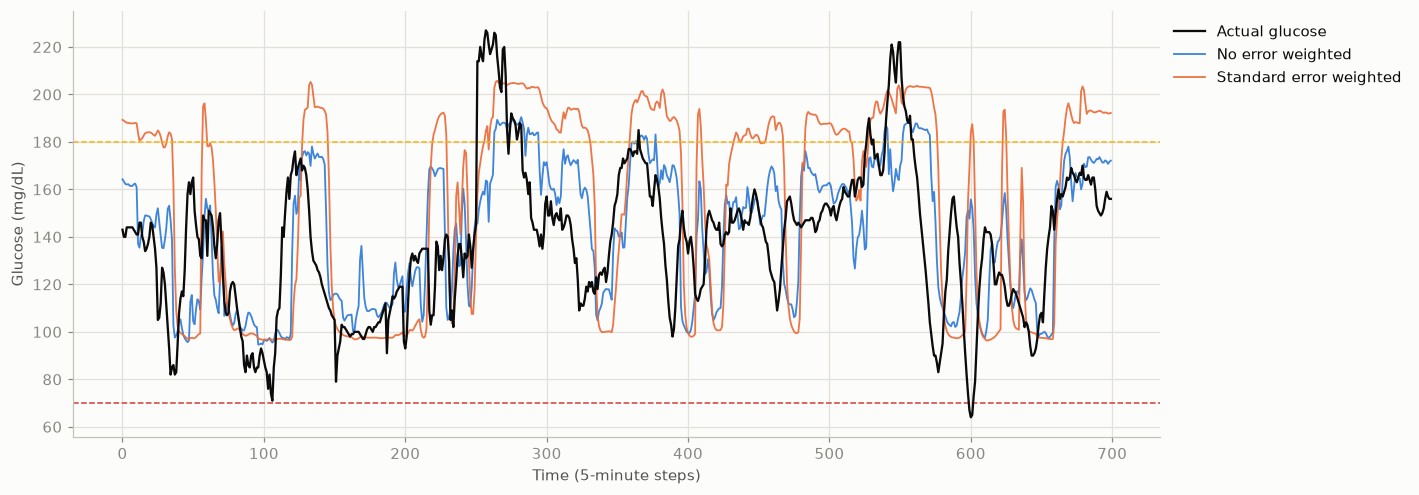

In [2]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(actual[:WINDOW], color=plotting.INK_PRIMARY, linewidth=1.5, label="Actual glucose", zorder=5)
for name, (_, color) in MODELS.items():
    ax.plot(frames[name].pred[:WINDOW], color=color, linewidth=1.2, alpha=0.9, label=name)
ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
ax.set_xlabel("Time (5-minute steps)")
ax.set_ylabel("Glucose (mg/dL)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
plt.show()

## 2. GARCH error bands

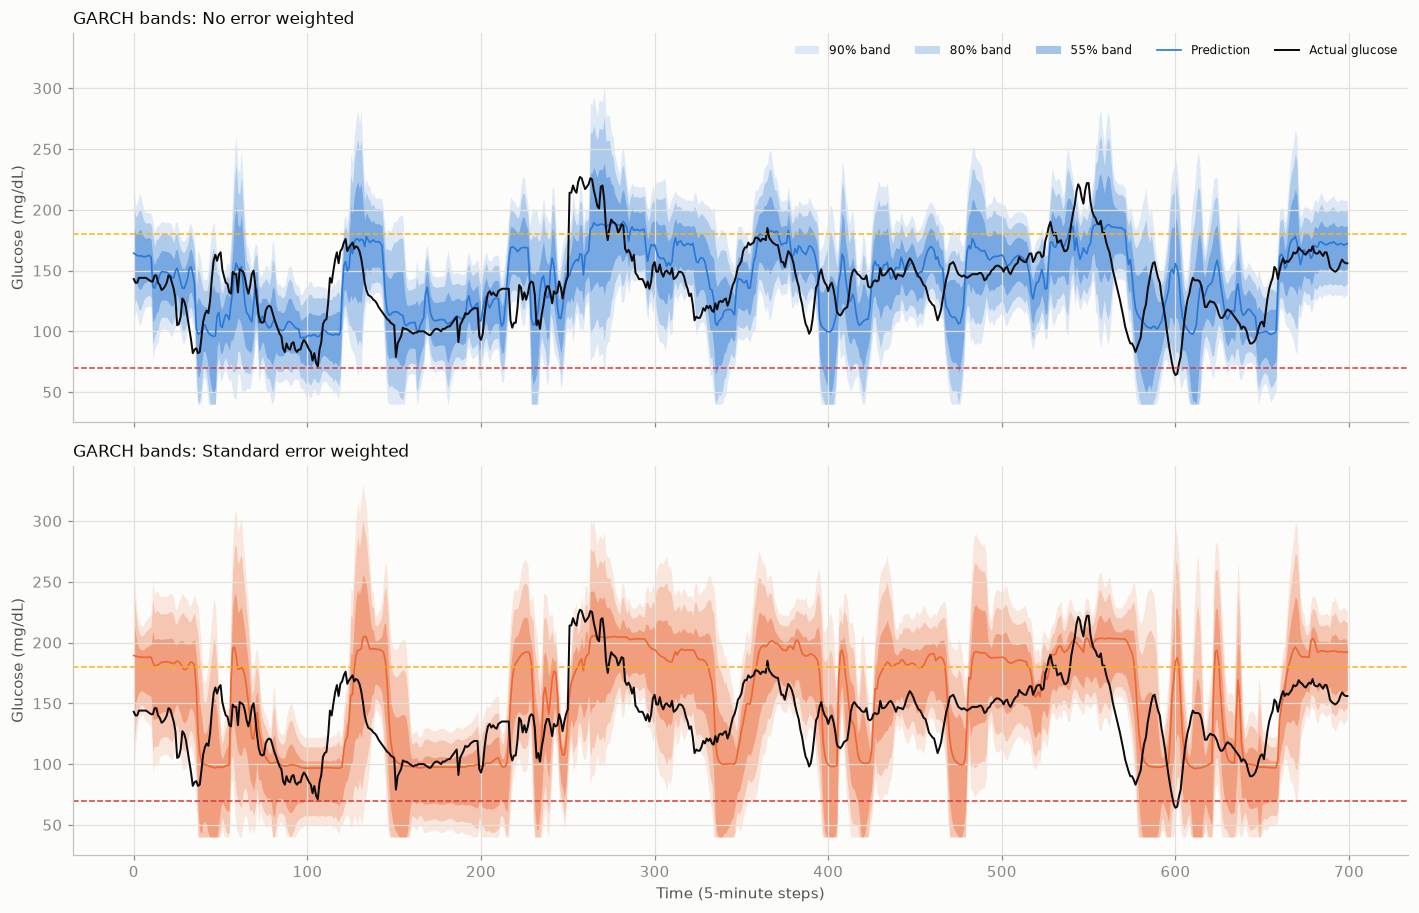

In [3]:
BAND_LEVELS = (0.90, 0.80, 0.55)          # widest first so the narrower ones draw on top
BAND_ALPHA = {0.90: 0.14, 0.80: 0.26, 0.55: 0.42}

fig, axes = plt.subplots(2, 1, figsize=(13, 8.4), sharex=True, sharey=True)
for ax, (name, (_, color)) in zip(axes, MODELS.items()):
    for level in BAND_LEVELS:
        lo, hi = engines[name].bands("GARCH", level)
        ax.fill_between(np.arange(WINDOW), lo[:WINDOW], hi[:WINDOW], color=color, alpha=BAND_ALPHA[level], linewidth=0,
                        label=f"{int(level * 100)}% band")
    ax.plot(frames[name].pred[:WINDOW], color=color, linewidth=1.1, label="Prediction")
    ax.plot(actual[:WINDOW], color=plotting.INK_PRIMARY, linewidth=1.3, label="Actual glucose")
    ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
    ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
    ax.set_ylabel("Glucose (mg/dL)")
    ax.set_title(f"GARCH bands: {name}", loc="left", fontsize=11)
axes[0].legend(frameon=False, ncol=5, loc="upper right", fontsize=8)
axes[1].set_xlabel("Time (5-minute steps)")
fig.tight_layout()
plt.show()

## 3. Clarke Error Grid

Each dot compares real glucose (x axis) with the predicted glucose (y axis). The zones say how harmful the error would be if someone acted on the prediction:

- **A**: prediction within 20% of the real value (or both under 70). Clinically accurate.
- **B**: off by more than 20%, but acting on it would still not cause harm.
- **C**: off enough that acting on it would trigger an unneeded treatment.
- **D**: a dangerous miss. Real glucose is clearly out of range (under about 58 or over 240) but the prediction says it is in range.
- **E**: the prediction points the wrong way (a real low predicted as high, or a real high predicted as low). The worst error.

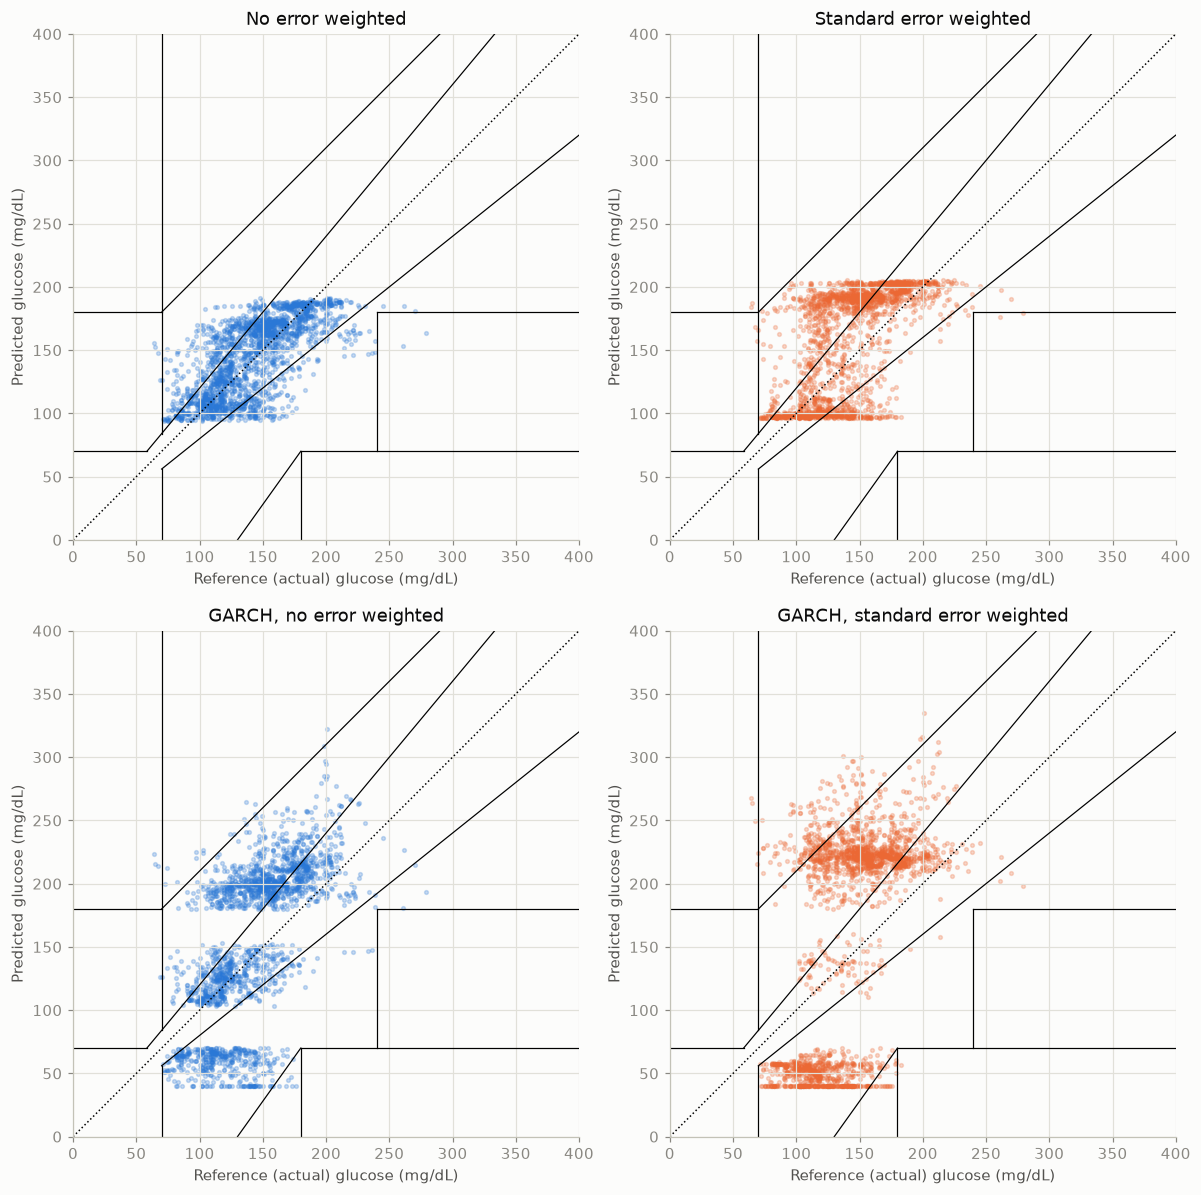

In [4]:
grid_predictions = {}
for name in MODELS:
    lo, hi = engines[name].bands("GARCH", GRID_LEVEL)
    grid_predictions[f"GARCH, {name.lower()}"] = unc.swapped_prediction(frames[name].pred, lo, hi)
panels = {name: frames[name].pred for name in MODELS} | grid_predictions
panel_colors = {**{n: c for n, (_, c) in MODELS.items()}, **{f"GARCH, {n.lower()}": c for n, (_, c) in MODELS.items()}}

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (title, pred) in zip(axes.ravel(), panels.items()):
    draw_clarke_grid(ax, actual, pred, panel_colors[title])
    ax.set_title(title)
fig.tight_layout()
plt.show()

In [5]:
zones = ["A", "B", "C", "D", "E"]
zone_table = pd.DataFrame({title: clarke_zone_percentages(actual, pred) for title, pred in panels.items()}).T[zones]
zone_table.round(2)

,A,B,C,D,E
No error weighted,73.63,26.05,0.00,0.32,0.00
Standard error weighted,52.42,47.26,0.00,0.23,0.09
"GARCH, no error weighted",36.38,62.38,1.01,0.09,0.14
"GARCH, standard error weighted",12.36,78.05,9.31,0.00,0.28


## 4. Clarke zones as the GARCH band grows: no error weighted

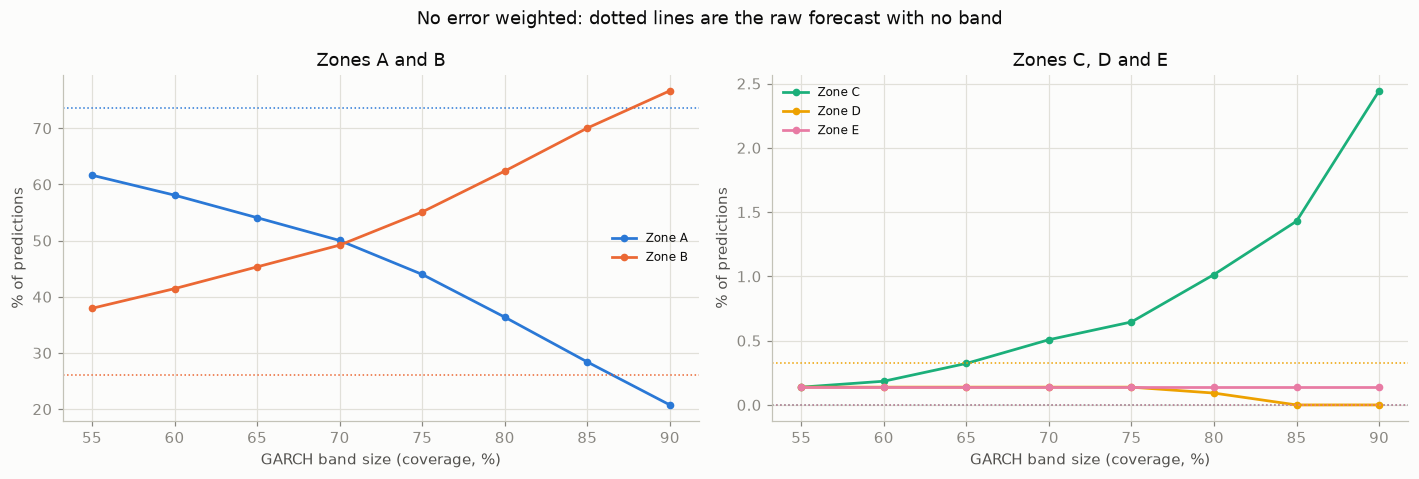

,A,B,C,D,E
band,,,,,
0.55,61.64,37.94,0.14,0.14,0.14
0.60,58.09,41.45,0.18,0.14,0.14
0.65,54.08,45.32,0.32,0.14,0.14
0.70,50.02,49.19,0.51,0.14,0.14
0.75,43.98,55.09,0.65,0.14,0.14
0.80,36.38,62.38,1.01,0.09,0.14
0.85,28.40,70.03,1.43,0.00,0.14
0.90,20.75,76.67,2.44,0.00,0.14


In [6]:
def zone_trend(name):
    rows = []
    for level in TREND_LEVELS:
        lo, hi = engines[name].bands("GARCH", float(level))
        rows.append({"band": level, **clarke_zone_percentages(actual, unc.swapped_prediction(frames[name].pred, lo, hi))})
    return pd.DataFrame(rows).set_index("band")


def plot_trend(name):
    trend = zone_trend(name)
    base = clarke_zone_percentages(actual, frames[name].pred)
    zone_color = dict(zip("ABCDE", plotting.CATEGORICAL[:5]))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharex=True)
    for ax, group, title in ((axes[0], "AB", "Zones A and B"), (axes[1], "CDE", "Zones C, D and E")):
        for z in group:
            ax.plot(trend.index * 100, trend[z], marker="o", markersize=4, color=zone_color[z], linewidth=1.8, label=f"Zone {z}")
            ax.axhline(base[z], linestyle=":", color=zone_color[z], linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("GARCH band size (coverage, %)")
        ax.set_ylabel("% of predictions")
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(f"{name}: dotted lines are the raw forecast with no band")
    fig.tight_layout()
    plt.show()
    return trend


trend_none = plot_trend("No error weighted")
trend_none.round(2)

## 5. Clarke zones as the GARCH band grows: standard error weighted

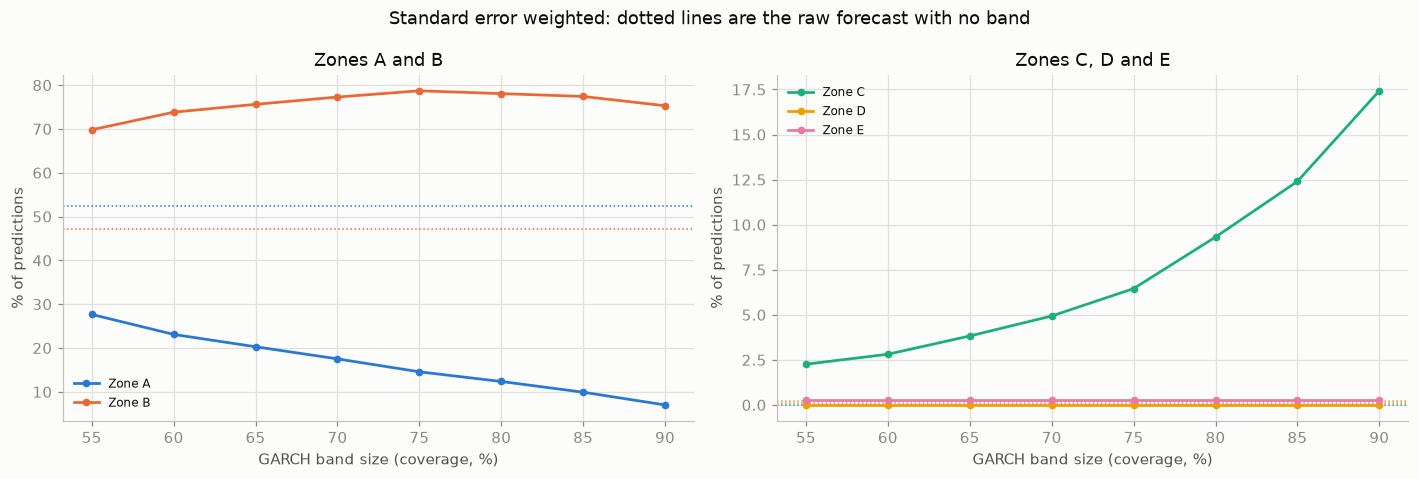

,A,B,C,D,E
band,,,,,
0.55,27.66,69.80,2.26,0.0,0.28
0.60,23.10,73.81,2.81,0.0,0.28
0.65,20.29,75.61,3.83,0.0,0.28
0.70,17.52,77.27,4.93,0.0,0.28
0.75,14.57,78.70,6.45,0.0,0.28
0.80,12.36,78.05,9.31,0.0,0.28
0.85,9.91,77.41,12.40,0.0,0.28
0.90,7.01,75.29,17.43,0.0,0.28


In [7]:
trend_standard = plot_trend("Standard error weighted")
trend_standard.round(2)

## 6. Where the alarm fires

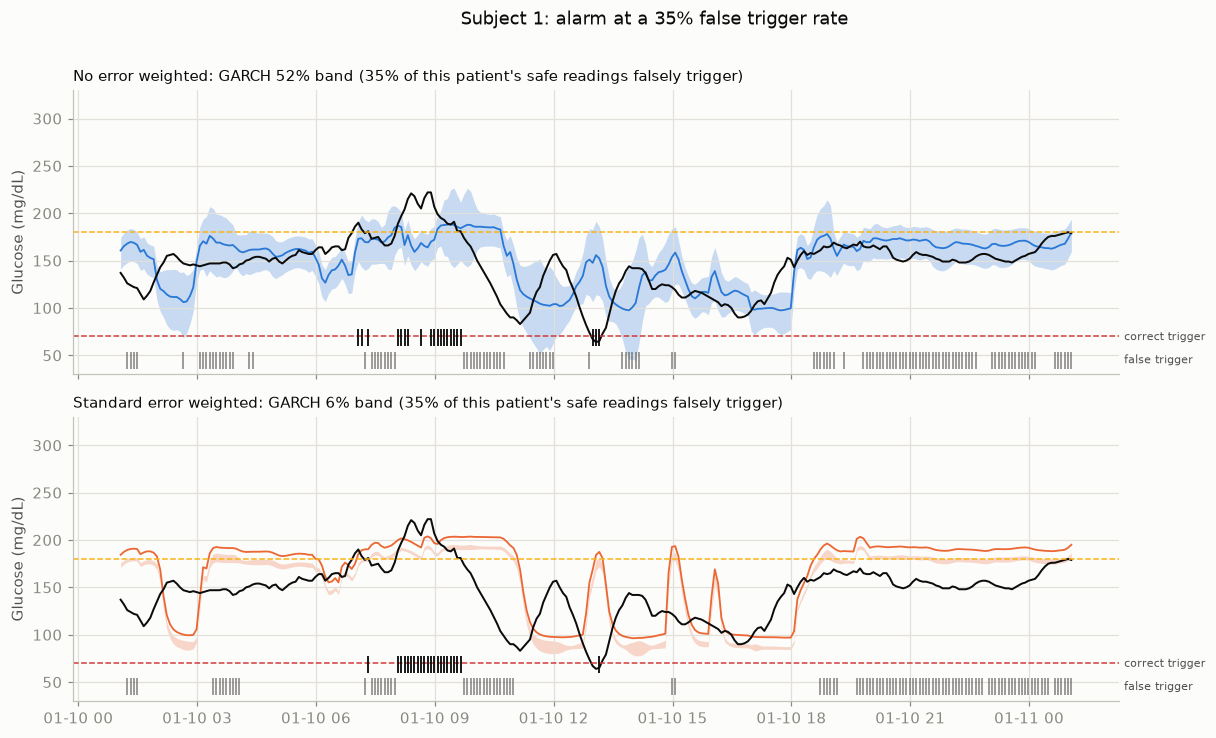

In [8]:
TRIGGER_HALF_WINDOW = 144     # 24 hours in total, centered on this patient's lowest real glucose reading
TARGET_FALSE_RATE = 0.35


def plot_triggers(levels, suptitle):
    """One panel per model. Ticks along the bottom mark the moments the alarm fires: upper row = correct
    (real glucose in danger), lower row = false (real glucose safe)."""
    center = int(np.argmin(actual))
    a, b = max(0, center - TRIGGER_HALF_WINDOW), min(len(actual), center + TRIGGER_HALF_WINDOW)
    x = time[a:b]
    danger = (actual < ref.HYPO_THRESHOLD) | (actual > ref.HYPER_THRESHOLD)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True, sharey=True)
    for ax, (name, (_, color)) in zip(axes, MODELS.items()):
        lo, hi = engines[name].bands("GARCH", levels[name])
        trig, _, _ = unc.trigger_flags(lo, hi)
        rate = unc.trigger_metrics(actual, lo, hi)["false_trigger_rate"]
        ax.fill_between(x, lo[a:b], hi[a:b], color=color, alpha=0.25, linewidth=0)
        ax.plot(x, frames[name].pred[a:b], color=color, linewidth=1.2)
        ax.plot(x, actual[a:b], color=plotting.INK_PRIMARY, linewidth=1.3)
        ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
        ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
        ax.vlines(x[trig[a:b] & danger[a:b]], 60, 78, color=plotting.INK_PRIMARY, linewidth=1.2)
        ax.vlines(x[trig[a:b] & ~danger[a:b]], 36, 54, color=plotting.INK_SECONDARY, linewidth=1.2, alpha=0.6)
        ax.annotate("correct trigger", xy=(1.005, 69), xycoords=("axes fraction", "data"), fontsize=7, color=plotting.INK_SECONDARY, va="center", annotation_clip=False)
        ax.annotate("false trigger", xy=(1.005, 45), xycoords=("axes fraction", "data"), fontsize=7, color=plotting.INK_SECONDARY, va="center", annotation_clip=False)
        ax.set_ylim(30, 330)
        ax.set_ylabel("Glucose (mg/dL)")
        ax.set_title(f"{name}: GARCH {levels[name]:.0%} band ({rate:.0%} of this patient's safe readings falsely trigger)", loc="left", fontsize=10)
    fig.suptitle(suptitle)
    fig.tight_layout(rect=[0, 0, 0.93, 0.97])
    plt.show()


# Band size that gives this patient a 35% false trigger rate, found separately for each model
matched_levels = {
    name: unc.level_for_false_trigger_rate({SUBJECT_ID: engines[name]}, {SUBJECT_ID: actual}, "GARCH", TARGET_FALSE_RATE)
    for name in MODELS
}
plot_triggers(matched_levels, f"Subject {SUBJECT_ID}: alarm at a {TARGET_FALSE_RATE:.0%} false trigger rate")

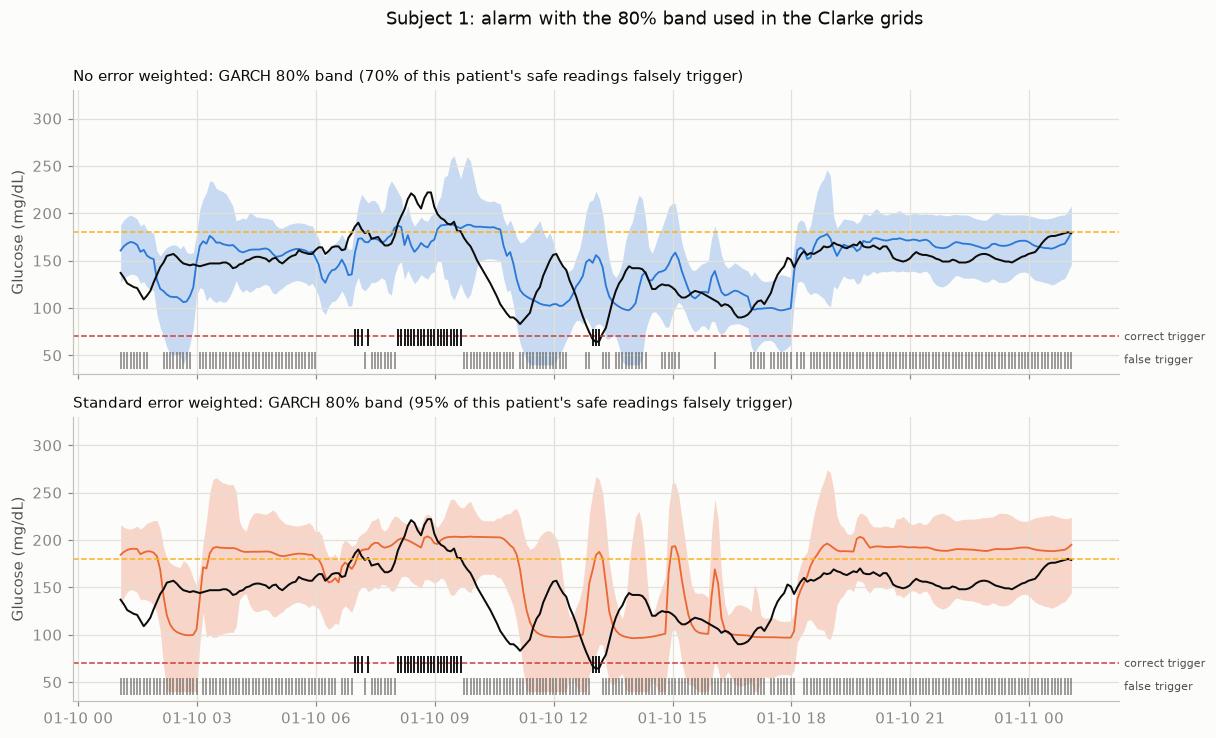

In [9]:
plot_triggers({name: GRID_LEVEL for name in MODELS}, f"Subject {SUBJECT_ID}: alarm with the {GRID_LEVEL:.0%} band used in the Clarke grids")